# 03_06. SR validation of LR novel splice junctions (option-1 molecule-object isoform filter)

Validates novel splice junctions from long-read data against a matched STARsolo short-read
splice-junction (SJ) catalog, **across all matched short-read samples** (48 tissues;
TSP21/25/27/33). Junctions are matched by exact genomic coordinate. Controls: LR **known**
junctions (positive) and coordinate-**shifted** decoys (false-positive floor).

Sections 1–2 summarise validation rates atlas-wide; sections 3–4 (per-junction SR support depth
and LR-expression dependence) pool all samples; section 5 asks whether the *same cells* that
express a junction's isoform in long-read detect it in short-read; section 6 asks whether
validation depends on where the junction sits along the transcript.

**Option-1 variant:** the target set is drawn from isoforms present in the preprocessed molecules
object (02a cell-based QC) rather than an FL>=5 cut. Canonical GT-AG restriction, decoy (+137 bp)
and known controls are unchanged.

### Two definitional choices, both declared in the setup cell

| choice | setting | meaning |
|---|---|---|
| **Carrier-isoform scope** | none | a novel canonical junction counts whatever structural category its carrier isoform has — a **junction-level** definition |
| **Dedup** | both arms | novel and known are counted as **distinct (chrom, start, end) within each tissue**, not once per carrier isoform |

The carrier filter is applied **upstream**, in `build_targets()` in
`validate_all_samples_option1.py`, so it cannot be undone in the notebook — the per-junction
files simply do not contain junctions of non-NIC/NNC carriers. Removing it needs that script
re-run with `CARRIER=any`
(`sbatch sr_junction_validation/run_validate_option1_anycarrier.sbatch`), which writes to
`validation_option1_anycarrier/`. **The setup cell auto-detects that directory** and switches to
it the moment it exists; until then it uses the novel-only outputs and prints a notice, so the
notebook always runs and always says which population it is describing.

Section 6 reads a different, position-resolved build
(`validation_positions_option1_allknown_robust_all/`) and has never applied the carrier filter,
so it is already junction-level.

In [2]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# preferred plot formatting
PANEL_TITLE_PAD = 3.0
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"] + matplotlib.rcParams["font.sans-serif"]
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6, "xtick.labelsize": 6,
    "ytick.labelsize": 6, "legend.fontsize": 6, "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "figure.titlesize": 6, "axes.labelweight": "bold", "axes.titleweight": "bold",
    "figure.titleweight": "bold", "xtick.major.size": 2.0, "ytick.major.size": 2.0,
    "xtick.major.pad": 1.5, "ytick.major.pad": 1.5, "axes.labelpad": 1.5,
})
os.makedirs("figures", exist_ok=True)

# CARRIER-ISOFORM SCOPE (see the header cell): no carrier filter -- it lives upstream in
# build_targets(). This block auto-detects the carrier-unfiltered outputs once they exist.
VALDIR_ANY = "./../sr_junction_validation/validation_option1_anycarrier"
VALDIR_NOV = "./../sr_junction_validation/validation_option1"
if os.path.exists(f"{VALDIR_ANY}/all_samples_junction_validation_summary.csv"):
    VALDIR, CARRIER_SCOPE = VALDIR_ANY, "any carrier isoform"
else:
    VALDIR, CARRIER_SCOPE = VALDIR_NOV, "NIC/NNC carriers only"
    print("!! carrier-unfiltered outputs not found, using the novel-only target set:")
    print("   sections 1-5 still apply the carrier-isoform filter that section 6 does not.")
    print("   to remove it: sbatch sr_junction_validation/run_validate_option1_anycarrier.sbatch\n")
SUMMARY_ALL = f"{VALDIR}/all_samples_junction_validation_summary.csv"
print(f"target set: {VALDIR}\n            (carrier scope: {CARRIER_SCOPE})")

# CANONICAL ONLY. The pipeline emits both classes and keeps `canonical` on every row, so this
# is a notebook-side subset and can be widened again without re-running anything.
#
# Why canonical only: novel non-canonical junctions validate at 0.0% (0 of 92,431) while novel
# canonical reach ~40%, so pooling them averages two populations that behave nothing alike and
# drags the headline rate down by a fixed ~4% dilution that says nothing about splicing. The
# non-canonical result is a finding in its own right -- reported once in section 1 -- not a
# component of the validation rate. Flip SETS_PREFERRED and NOVEL_CANONICAL_ONLY to include it.
SETS_PREFERRED = ["LR_novel__canonical", "LR_known__canonical", "decoy_shift137__canonical"]
NOVEL_CANONICAL_ONLY = True
SETS_POOLED = ["LR_novel", "LR_known", "decoy_shift137"]   # fallback for pre-split outputs
SET_LABELS = {
    "LR_novel__canonical":     "Novel\ncanonical",
    "LR_novel__non_canonical": "Novel\nnon-canon.",
    "LR_known__canonical":     "Known\ncanonical",
    "LR_known__non_canonical": "Known\nnon-canon.",
    "decoy_shift137__canonical": "Decoy\n(shifted)",
    "decoy_shift137":          "Decoy\n(shifted)",
    "LR_novel": "Novel\n(any carrier)", "LR_known": "Known\n(FSM/ISM)",
}
SPOTLIGHT = "T16"                       # deepest sample, used for the per-cell section
SPOTLIGHT_NAME = "TSP33 Testis (T16)"

# ---------------------------------------------------------------------------------
# JUNCTION DEDUP CONVENTION -- the single place it is declared, applies notebook-wide
# ---------------------------------------------------------------------------------
# How a junction is COUNTED when the same genomic coordinate recurs within a tissue.
# BOTH arms are deduplicated to distinct (chrom, start, end): the unit of analysis is the
# distinct junction, matching the question ("do novel junctions validate?").
#
# Why not occurrence-weight (one row per (isoform, junction), as the upstream script does
# for the novel arm)? Two reasons, both measured on T20/T21/T22:
#   1. Recurrence is confounded with the outcome. A junction carried by many isoforms sits
#      in a well-expressed, well-covered locus, so deduplicating LOWERS every arm's rate
#      (novel by 1.6-2.9 pp, known by 9.5-12.4 pp). Occurrence-weighting therefore smuggles
#      coverage back in -- exactly what the known control exists to remove.
#   2. Pseudo-replication. Repeated copies of one junction are not independent observations,
#      but the binomial CIs and any logistic fit treat every row as one. Occurrence-weighting
#      inflates n without adding information and makes the errors anticonservative.
# Mixing the two (the previous setting: novel occurrence-weighted, known deduplicated) was
# the worst option -- it inflates novel and deflates known simultaneously, shrinking the gap
# by ~10 pp relative to either consistent convention.
#
# A junction present in several tissues still counts once PER TISSUE, in both arms. That is
# right for per-tissue rates and for the position analysis (a junction's position depends on
# the tissue's isoform models); an atlas-level "N distinct novel junctions" figure would need
# a further global dedup.
DEDUP_NOVEL = True         # novel junctions: distinct coordinates within each tissue
DEDUP_KNOWN = True         # known junctions: distinct coordinates within each tissue
DEDUP_LABEL = {True: "distinct coords", False: "occurrence-weighted"}

# What validate_all_samples_option1.py writes into all_samples_junction_validation_summary.csv.
# It deduplicates the novel and decoy arms too (the known arm always was), so the summary
# and this notebook agree and no section carries a mixed convention.
# Kept as an explicit guard: if the two ever diverge again, the checks below fire rather than
# letting an occurrence-weighted rate be quoted against a deduplicated one.
UPSTREAM_DEDUP = (True, True)    # (novel, known)

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


target set: ./../sr_junction_validation/validation_option1_anycarrier
            (carrier scope: any carrier isoform)


## 1. Load validation results

In [3]:
# --- atlas-wide summary: one row per (sample, set) ---
summ_all = pd.read_csv(SUMMARY_ALL)
n_samples = summ_all["tissue"].nunique()
print(f"Samples validated: {n_samples} | sets: {sorted(summ_all['set'].unique())}")
# Use the split sets when the summary carries them; fall back to the pooled names otherwise.
_avail = set(summ_all["set"].unique())
SETS = [x for x in SETS_PREFERRED if x in _avail] or SETS_POOLED
if SETS == SETS_POOLED:
    print("  note: this summary has no canonical/non-canonical split; using pooled sets. "
          "Re-run validate_all_samples_option1.py to get the split.")
# Single place naming the arms used for per-tissue / per-sample views. Canonical is the primary
# novel population: the non-canonical arm validates at 0% everywhere, so plotting it per tissue
# would just draw a flat zero and compress the axis for the arm that actually varies.
NOVEL_SET = "LR_novel__canonical" if "LR_novel__canonical" in _avail else "LR_novel"
KNOWN_SET = "LR_known__canonical" if "LR_known__canonical" in _avail else "LR_known"
DECOY_SET = "decoy_shift137__canonical" if "decoy_shift137__canonical" in _avail else "decoy_shift137"
print(f"Dedup convention (setup cell): novel {DEDUP_LABEL[DEDUP_NOVEL]}, "
      f"known {DEDUP_LABEL[DEDUP_KNOWN]}")
if (DEDUP_NOVEL, DEDUP_KNOWN) != UPSTREAM_DEDUP:
    print(f"  !! summary CSV convention (novel={DEDUP_LABEL[UPSTREAM_DEDUP[0]]}, "
          f"known={DEDUP_LABEL[UPSTREAM_DEDUP[1]]}) differs from this notebook's. Rates taken "
          f"from the summary are then NOT comparable with those re-derived here.")

# absolute fraction of ALL junctions, by CELL support and by MOLECULE (SR read) support.
# cells>=k / reads>=k in the summary are conditional on being matched -> multiply by match_frac.
# The >=5 thresholds are deliberately not carried, on either measure: >=5 cells and >=5 reads
# tracked each other to within 0.1 pp at this depth (n_cells and n_reads are near-identical),
# so the pair was one measurement reported twice. cells>=5 / reads>=5 are still in the summary
# CSV if they are ever wanted back.
summ_all["abs_matched"]   = summ_all["match_frac"]
summ_all["abs_ge1"]       = (summ_all["match_frac"] * summ_all["cells>=1"]).fillna(0.0)
summ_all["abs_reads_ge1"] = (summ_all["match_frac"] * summ_all["reads>=1"]).fillna(0.0)

print("\nMean across samples (abs fraction of all junctions):")
for s in SETS:
    d = summ_all[summ_all["set"] == s]
    print(f"  {s:15s} matched {d['abs_matched'].mean():.1%}"
          f" | CELL >=1 {d['abs_ge1'].mean():.1%}"
          f" | MOLECULE(reads) >=1 {d['abs_reads_ge1'].mean():.1%}")

# per-tissue matched fraction, wide (tissue x set); feeds section 2
piv = summ_all.pivot_table(index="tissue", columns="set", values="match_frac")
print(f"\n{NOVEL_SET} match_frac across tissues: median {piv[NOVEL_SET].median():.1%}, "
      f"range {piv[NOVEL_SET].min():.1%} ({piv[NOVEL_SET].idxmin()}) - "
      f"{piv[NOVEL_SET].max():.1%} ({piv[NOVEL_SET].idxmax()})")

# --- pool per-junction support across all samples ---
# n_cells = # SR cells detecting the junction; n_reads = # SR reads (molecule support).
# Coordinates are read too, so the dedup convention can be applied here rather than inherited.
# Heavy read (48 files, up to ~30 MB each) -> run on a compute node.
supp_files = sorted(glob.glob(f"{VALDIR}/T*_novel_junction_SR_support.csv"))
frames = []
for fp in supp_files:
    t = re.match(r".*/(T\d+)_novel", fp).group(1)
    d = pd.read_csv(fp, usecols=["chrom", "start", "end", "isoform", "n_cells", "n_reads", "sr_matched",
                              "canonical"])
    d["tissue"] = t
    frames.append(d)
perj_all = pd.concat(frames, ignore_index=True)
del frames
perj_all["sr_matched"] = perj_all["sr_matched"].astype(bool)
perj_all["n_cells"] = pd.to_numeric(perj_all["n_cells"], errors="coerce")
perj_all["n_reads"] = pd.to_numeric(perj_all["n_reads"], errors="coerce")
n_novel_occurrences = len(perj_all)

# Cross-check that the summary and the per-junction support files describe the same data.
# The summary is now deduplicated on both arms while the support files are still written at
# occurrence level (validate_percell_all.py needs the isoform-level rows), so the identity is
# against the DISTINCT count, not the raw row count.
_pooled_raw = summ_all.groupby("set")[["n", "matched"]].sum()
_n_distinct_all = len(perj_all.drop_duplicates(["tissue", "chrom", "start", "end"]))
assert int(_pooled_raw.loc["LR_novel", "n"]) == _n_distinct_all, (
    f"summary LR_novel n={int(_pooled_raw.loc['LR_novel','n']):,} disagrees with the distinct "
    f"per-junction rows ({_n_distinct_all:,}) -- summary and support files are out of sync")

# Report the non-canonical arm ONCE, before subsetting, so the finding is on the record even
# though it takes no further part in the analysis. It is not a STAR filtering artefact: the SR
# catalogs hold ~13k non-canonical junctions per sample, >99% unannotated, and known
# non-canonical junctions validate at ~82%. The two platforms simply never call the same ones.
if "canonical" in perj_all.columns:
    # BOTH conventions, because this block runs before the deduplication below and an
    # occurrence-weighted rate here would silently disagree with the deduplicated rates printed
    # a few lines later in this same cell. Canonical junctions recur far more than
    # non-canonical ones (~1.02 observations each), so the two conventions diverge for
    # canonical and coincide for non-canonical.
    print("\nnovel junctions by splice-site motif (before subsetting):")
    for _c, _g in perj_all.groupby("canonical", observed=True):
        _d = _g.drop_duplicates(["tissue", "chrom", "start", "end"])
        print(f"    {_c:14s} occurrences {len(_g):>10,} ({_g['sr_matched'].mean():5.1%} matched)"
              f"  |  distinct {len(_d):>10,} ({_d['sr_matched'].mean():5.1%} matched)")
    print("    distinct is the reporting convention; occurrences are shown only to make the")
    print("    recurrence visible (canonical junctions repeat, non-canonical essentially never)")
    if NOVEL_CANONICAL_ONLY:
        _n0 = len(perj_all)
        perj_all = perj_all[perj_all["canonical"] == "canonical"].copy()
        print(f"  -> restricting to CANONICAL: {_n0:,} -> {len(perj_all):,} "
              f"({_n0 - len(perj_all):,} non-canonical dropped). Sections 1-5 are canonical-only.")

# Molecule support per junction, needed by section 4. Computed BEFORE dedup so that a
# deduplicated junction carries the TOTAL long-read support of every isoform that uses it,
# rather than an arbitrary carrier's count. Every option-1 target isoform is in the molecules
# object by construction, so no NaNs are expected.
_mm = pd.read_csv("./../csvs/pbids_object_isoform_counts.csv")
_mol = dict(zip(_mm["molecule_id"].astype(str), _mm["n_molecules"]))
perj_all["mol_count"] = perj_all["isoform"].astype(str).map(_mol)
_n_unmapped = int(perj_all["mol_count"].isna().sum())
if _n_unmapped:
    print(f"  warning: {_n_unmapped:,} rows have no molecule-object count (expected 0)")

_n_pre_dedup = len(perj_all)
if DEDUP_NOVEL:
    # n_cells / n_reads / sr_matched are functions of (tissue, chrom, start, end) alone --
    # they come from a coordinate join against the STARsolo SJ table -- so collapsing
    # duplicate coordinates is lossless on the SR side and "first" is exact. Only the
    # isoform-derived columns differ between copies, and mol_count is summed over carriers.
    perj_all = perj_all.groupby(["tissue", "chrom", "start", "end"], as_index=False).agg(
        isoform=("isoform", "first"), n_cells=("n_cells", "first"),
        n_reads=("n_reads", "first"), sr_matched=("sr_matched", "first"),
        canonical=("canonical", "first"),   # a property of the coordinate, so "first" is exact
        mol_count=("mol_count", "sum"))
    # count the rows actually entering dedup, NOT n_novel_occurrences: that was captured before
    # the canonical subset above (it exists for the assert against the summary), so using it here
    # would report the pre-subset total and an inflated collapse rate.
    print(f"\nNovel junctions deduplicated within tissue: {_n_pre_dedup:,} occurrences "
          f"-> {len(perj_all):,} distinct (tissue, coordinate) "
          f"({1 - len(perj_all)/_n_pre_dedup:.1%} collapsed)")

MOLCOUNT_LABEL = ("Molecules per junction" if DEDUP_NOVEL
                  else "Molecules per isoform (molecule object)")

print(f"\nPooled novel junctions across {len(supp_files)} samples: {len(perj_all):,} "
      f"| coord-matched: {perj_all['sr_matched'].mean():.1%} ({DEDUP_LABEL[DEDUP_NOVEL]})")

# Per-sample mean on the SAME deduplicated basis as the known arm, which is what any "mean rate
# per sample" claim needs. The [upstream] block above reports 46.4% for novel, but that number is
# OCCURRENCE-WEIGHTED -- validate_all_samples_option1.py does not deduplicate the novel arm --
# while its known figure IS deduplicated. Quoting the two side by side mixes conventions and
# overstates novel by ~8 points. Recomputed here so both arms are counted the same way.
_per_sample = perj_all.groupby("tissue", observed=True)["sr_matched"].mean()
print(f"  per-sample mean, re-derived from the support files: {_per_sample.mean():.1%} "
      f"(median {_per_sample.median():.1%}, range {_per_sample.min():.1%}-{_per_sample.max():.1%})")
print(f"  (independent cross-check of the summary's own mean printed above)")

# Same pooled quantity for the other two sets, from the summary's raw n / matched counts --
# the per-junction support files exist only for LR_novel, so these keep the upstream
# convention and are NOT like-for-like with the novel line above.
pooled = _pooled_raw.copy()
pooled["frac"] = pooled["matched"] / pooled["n"]
_dedup_of = {"LR_novel": UPSTREAM_DEDUP[0], "LR_known": UPSTREAM_DEDUP[1],
             "decoy_shift137": UPSTREAM_DEDUP[0]}
for s in ["LR_known", "decoy_shift137"]:
    print(f"Pooled {s} junctions across {n_samples} samples: {pooled.loc[s, 'n']:,} "
          f"| coord-matched: {pooled.loc[s, 'frac']:.1%} ({DEDUP_LABEL[_dedup_of[s]]})")

# spotlight sample (deepest) for reference
perj = perj_all[perj_all["tissue"] == SPOTLIGHT].copy()
print(f"Spotlight {SPOTLIGHT}: {len(perj):,} novel junctions, "
      f"coord-matched {perj['sr_matched'].mean():.1%}")

Samples validated: 48 | sets: ['LR_known', 'LR_known__canonical', 'LR_known__non_canonical', 'LR_novel', 'LR_novel__canonical', 'LR_novel__non_canonical', 'decoy_shift137', 'decoy_shift137__canonical', 'decoy_shift137__non_canonical']
Dedup convention (setup cell): novel distinct coords, known distinct coords

Mean across samples (abs fraction of all junctions):
  LR_novel__canonical matched 38.6% | CELL >=1 29.9% | MOLECULE(reads) >=1 29.9%
  LR_known__canonical matched 79.7% | CELL >=1 67.4% | MOLECULE(reads) >=1 67.4%
  decoy_shift137__canonical matched 0.0% | CELL >=1 0.0% | MOLECULE(reads) >=1 0.0%

LR_novel__canonical match_frac across tissues: median 37.8%, range 16.6% (T41) - 75.5% (T16)

novel junctions by splice-site motif (before subsetting):
    canonical      occurrences  3,291,089 (48.4% matched)  |  distinct  2,374,498 (39.6% matched)
    non_canonical  occurrences     92,431 ( 0.0% matched)  |  distinct     92,431 ( 0.0% matched)
    distinct is the reporting convention

### Atlas-wide union: confirmed in at least one sample


In [4]:
_union = (perj_all
          .groupby(["chrom", "start", "end"], observed=True, as_index=False)
          .agg(sr_matched=("sr_matched", "any"), n_samples=("tissue", "nunique")))

n_union_total = len(_union)
n_union_conf = int(_union["sr_matched"].sum())
union_frac = n_union_conf / n_union_total if n_union_total else float("nan")

print(f"ATLAS-WIDE UNION over {perj_all['tissue'].nunique()} SR-matched samples")
print(f"  distinct novel canonical junctions : {n_union_total:,}")
print(f"  confirmed in >=1 sample            : {n_union_conf:,} ({union_frac:.1%})")
print(f"  (for contrast, per-(tissue, coord) : {perj_all['sr_matched'].mean():.1%})")

_union["breadth"] = pd.cut(_union["n_samples"], [0, 1, 2, 5, 10, 10**9],
                           labels=["1", "2", "3-5", "6-10", ">10"])
_breadth = (_union.groupby("breadth", observed=True)
            .agg(junctions=("sr_matched", "size"), confirmed=("sr_matched", "sum")))
_breadth["rate"] = _breadth["confirmed"] / _breadth["junctions"]
print("\nunion rate by how many samples the junction appears in:")
print(_breadth.to_string(formatters={"rate": "{:.1%}".format}))

_breadth


ATLAS-WIDE UNION over 48 SR-matched samples
  distinct novel canonical junctions : 223,567
  confirmed in >=1 sample            : 154,843 (69.3%)
  (for contrast, per-(tissue, coord) : 39.6%)

union rate by how many samples the junction appears in:
         junctions  confirmed  rate
breadth                            
1            25050       6425 25.6%
2            42117      33431 79.4%
3-5          26615      16291 61.2%
6-10         46442      29885 64.3%
>10          83343      68811 82.6%


,junctions,confirmed,rate
breadth,,,
1,25050,6425,0.256487
2,42117,33431,0.793765
3-5,26615,16291,0.612098
6-10,46442,29885,0.643491
>10,83343,68811,0.825636


## 2. Validation rates: novel vs known vs decoy

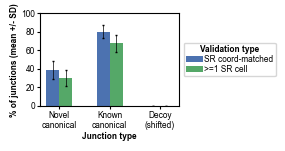

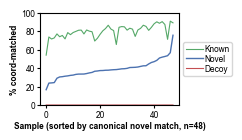

LR_novel__canonical mean coord-matched 38.6% (median 37.8%, range 16.6%-75.5%)
LR_known__canonical mean coord-matched 79.7% (median 80.9%, range 54.0%-90.8%)
decoy_shift137__canonical mean coord-matched 0.0% (median 0.0%, range 0.0%-0.0%)


In [5]:
# Atlas-wide validation rates, one figure per panel:
#   (a) mean +/- SD across samples per set
#   (b) per-sample distribution
#
# Both panels come from the summary CSV, which deduplicates every arm, so they are on the
# same basis as the rest of the notebook. Guard retained in case that changes.
if (DEDUP_NOVEL, DEDUP_KNOWN) != UPSTREAM_DEDUP:
    print(f"!! figures below use the summary convention (novel="
          f"{DEDUP_LABEL[UPSTREAM_DEDUP[0]]}, known={DEDUP_LABEL[UPSTREAM_DEDUP[1]]}), which is "
          f"NOT this notebook's -- do not compare them with sections 3-6.\n")

# --- (a) mean +/- SD across samples: coord-matched / >=1 SR cell, per set ---
# Bar offsets are centred on len(BARS) so removing or adding a series keeps the group centred --
# a hardcoded (k - 1) would push a two-bar group off its tick.
BARS = [("abs_matched", "SR coord-matched", "#4c72b0"),
        ("abs_ge1", ">=1 SR cell", "#55a868")]
fig, ax = plt.subplots(figsize=(1.8, 1.2))
x = np.arange(len(SETS)); w = 0.26
for k, (col, lab, color) in enumerate(BARS):
    means = [summ_all.loc[summ_all["set"] == s, col].mean() * 100 for s in SETS]
    sds   = [summ_all.loc[summ_all["set"] == s, col].std() * 100 for s in SETS]
    ax.bar(x + (k - (len(BARS) - 1) / 2) * w, means, w, yerr=sds,
           error_kw=dict(lw=0.5, capsize=1), label=lab, color=color)
ax.set_xticks(x); ax.set_xticklabels([SET_LABELS[s] for s in SETS])
ax.set_xlabel(f"Junction type")
ax.set_ylabel("% of junctions (mean +/- SD)"); ax.set_ylim(0, 100)
# ax.set_title(f"SR validation across {n_samples} samples", pad=PANEL_TITLE_PAD)
leg = ax.legend(loc=6, bbox_to_anchor=(1.0, 0.5), title = "Validation type")
leg.get_title().set_fontweight("bold")
plt.savefig(figpath("03_06b_sr_junction_validation_rates_by_set.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# --- (b) per-sample coord-matched fraction, samples sorted by novel rate ---
fig, ax2 = plt.subplots(figsize=(1.8, 1.2))
# sorted by the canonical novel rate -- the arm that varies across tissues
order = piv[NOVEL_SET].sort_values().index
xt = np.arange(len(order))
ax2.plot(xt, piv.loc[order, KNOWN_SET] * 100, "-", lw=0.8, color="#55a868", label="Known")
ax2.plot(xt, piv.loc[order, NOVEL_SET] * 100, "-", lw=1.0, color="#4c72b0", label="Novel")
ax2.plot(xt, piv.loc[order, DECOY_SET] * 100, "-", lw=0.8, color="#c44e52", label="Decoy")
ax2.set_xlabel(f"Sample (sorted by canonical novel match, n={len(order)})")
ax2.set_ylabel("% coord-matched"); ax2.set_ylim(0, 100)
# ax2.set_title("Per-sample validation rate", pad=PANEL_TITLE_PAD)
leg2 = ax2.legend(loc=6, bbox_to_anchor=(1.0, 0.5)); leg2.get_title().set_fontweight("bold")
plt.savefig(figpath("03_06b_sr_junction_validation_rates_per_sample.pdf"),  dpi=300)
plt.show()

for s in SETS:
    d = summ_all[summ_all["set"] == s]["match_frac"]
    print(f"{s:15s} mean coord-matched {d.mean():.1%} "
          f"(median {d.median():.1%}, range {d.min():.1%}-{d.max():.1%})")

## 3. Short-read support depth of validated novel junctions

/tmp/ipykernel_6435/3822748231.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


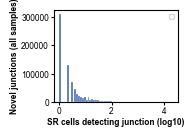

/tmp/ipykernel_6435/3822748231.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


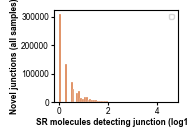

validated novel junctions: cell support median 2 | molecule support median 2


In [6]:
# Pooled across all samples: SR support depth of coord-matched novel junctions,
# by CELLS (n_cells) and by MOLECULES / SR reads (n_reads). One figure per measure.
matched = perj_all["sr_matched"]
sup_cells = perj_all.loc[matched & (perj_all["n_cells"] > 0), "n_cells"]
sup_mol   = perj_all.loc[matched & (perj_all["n_reads"] > 0), "n_reads"]

for sup, lab, col, title, fname in [
        (sup_cells, "cells", "#4c72b0", "Cell support",
         "03_06b_sr_support_depth_cells_allsamples.pdf"),
        (sup_mol, "molecules", "#dd8452", "Molecule (SR read) support",
         "03_06b_sr_support_depth_molecules_allsamples.pdf")]:
    fig, ax = plt.subplots(figsize=(1.6, 1.2))
    ax.hist(np.log10(sup), bins=60, color=col, edgecolor="white", linewidth=0.2)
    med = sup.median()
    # ax.axvline(np.log10(med), color="red", ls="--", lw=0.8, label=f"median {med:.0f}")
    ax.set_xlabel(f"SR {lab} detecting junction (log10)")
    ax.set_ylabel("Novel junctions (all samples)")
    # ax.set_title(f"{title}\n{n_samples} samples pooled", pad=PANEL_TITLE_PAD)
    ax.legend()
    plt.savefig(figpath(fname), dpi=300)
    plt.show()

# The >=5 fractions are not reported on either measure: >=5 cells and >=5 reads duplicated
# each other to within 0.1 pp. The full distributions are in the histograms above.
print(f"validated novel junctions: cell support median {sup_cells.median():.0f} | "
      f"molecule support median {sup_mol.median():.0f}")

## 4. Does LR expression predict validation?

Bin novel junctions by their long-read molecule support from the preprocessed pbids object
and plot the SR-validation fraction per bin. Because the novel arm is deduplicated, each distinct
junction is binned by the TOTAL molecule count summed over every isoform that carries it, not by
one arbitrary carrier's count. The measure is FL-independent, consistent with the option-1
molecule-object filter.

Restricted to canonical junctions. Non-canonical ones are excluded upstream in section 1, and
their rate is reported there.

/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks/figures/03_06b_validation_vs_molecule_count_cells_allsamples.pdf


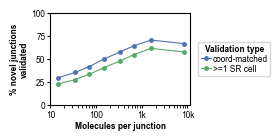

/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks/figures/suppfigure6/03_06b_validation_vs_molecule_count_reads_allsamples.pdf


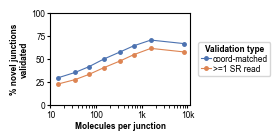

binned by: Molecules per junction | novel arm distinct coords
x positions (median mol_count per bin): <=25=15, 25-50=35, 50-100=70, 100-250=149, 250-500=337, 500-1k=667, 1k-5k=1,580, 5k+=8,186
cell1 identical to read1 across all bins: True  <- the two panels above carry the same information
          matched     cell1     read1  mol_med       n
mc_bin                                                
<=25     0.295644  0.228018  0.228018     15.0  876699
25-50    0.352544  0.275054  0.275054     35.0  484989
50-100   0.414704  0.331079  0.331079     70.0  380447
100-250  0.498056  0.404490  0.404490    149.0  336097
250-500  0.574656  0.477010  0.477010    337.0  147932
500-1k   0.640613  0.544531  0.544531    667.0   80192
1k-5k    0.702808  0.612984  0.612984   1580.0   59305
5k+      0.665158  0.574969  0.574969   8186.0    8837


In [7]:
# Pooled across all samples: bin novel junctions by their long-read molecule support from the
# preprocessed MOLECULE OBJECT - self-consistent with the option-1 molecule-object filter, and
# FL-free. `mol_count` is computed in section 1: per carrier isoform when the novel arm is
# occurrence-weighted, or SUMMED over every carrier isoform when it is deduplicated (so a
# distinct junction is binned by the total LR evidence behind it, not an arbitrary carrier's).
# Plot SR-validation fraction per bin, by CELL support and by MOLECULE (SR read) support.
#
# No >=5 series on either panel: >=5 cells and >=5 reads tracked each other to within 0.1 pp,
# so the pair was one measurement drawn twice. NOTE that cell1 and read1 are likewise near
# identical (a junction seen by >=1 cell is seen by >=1 read essentially always), so the two
# panels below now differ only in that near-degenerate series -- see the printed table.
# perj_all is already canonical-only (subset in section 1), so no filtering is needed here.
perj_all["matched_cell_ge1"] = perj_all["sr_matched"] & (perj_all["n_cells"].fillna(0) >= 1)
perj_all["matched_read_ge1"] = perj_all["sr_matched"] & (perj_all["n_reads"].fillna(0) >= 1)
mc_bins = [0, 25, 50, 100, 250, 500, 1000, 5000, np.inf]
mc_lab = ["<=25", "25-50", "50-100", "100-250", "250-500", "500-1k", "1k-5k", "5k+"]
perj_all["mc_bin"] = pd.cut(perj_all["mol_count"], bins=mc_bins, labels=mc_lab, right=True)
g = perj_all.groupby("mc_bin", observed=True).agg(
        matched=("sr_matched", "mean"),
        cell1=("matched_cell_ge1", "mean"),
        read1=("matched_read_ge1", "mean"),
        mol_med=("mol_count", "median"),
        n=("sr_matched", "size")).reindex(mc_lab)

# CONTINUOUS LOG X-AXIS: the bins are log-spaced, so a categorical axis would flatten the
# trend. Each bin sits at the MEDIAN mol_count of its junctions, which also gives the
# open-ended 5k+ bin a defined position. Ticks derive from the data range.
xb = g["mol_med"].to_numpy(float)


def _fmt_mol(v):
    return f"{v:.0f}" if v < 1000 else (f"{v/1000:.0f}k" if v < 1e6 else f"{v/1e6:.0f}M")


for title, series, fname in [
        ("Cell support",
         [("cell1", ">=1 SR cell", "#55a868")],
         "03_06b_validation_vs_molecule_count_cells_allsamples.pdf"),
        ("Molecule (SR read) support",
         [("read1", ">=1 SR read", "#dd8452")],
         "03_06b_validation_vs_molecule_count_reads_allsamples.pdf")]:
    fig, ax = plt.subplots(figsize=(1.8, 1.2))
    ax.plot(xb, g["matched"] * 100, "-o", ms=2.5, lw=0.8, color="#4c72b0", label="coord-matched")
    for key, lab, color in series:
        ax.plot(xb, g[key] * 100, "-o", ms=2.5, lw=0.8, color=color, label=lab)
    ax.set_xscale("log")
    _dec = 10.0 ** np.arange(np.floor(np.log10(xb.min())), np.ceil(np.log10(xb.max())) + 1)
    ax.set_xticks(_dec); ax.set_xticklabels([_fmt_mol(v) for v in _dec])
    ax.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(subs=np.arange(2, 10), numticks=99))
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.set_xlabel(MOLCOUNT_LABEL)
    # two lines: the one-line ylabel is taller than the 0.92 in axes of a 2.2 x 1.2 in panel
    ax.set_ylabel("% novel junctions\nvalidated")
    ax.set_ylim(0, 100); ax.set_yticks([0, 25, 50, 75, 100])
    # ax.set_title(title, pad=PANEL_TITLE_PAD)
    # legend moved INSIDE (lower right is empty - both curves rise left to right): outside-right
    # placement added ~1.5 in to the saved width via bbox_inches="tight".
    leg = ax.legend(loc=6, bbox_to_anchor=(1.05, 0.5), frameon=True,
                    handlelength=1.2, borderaxespad=0.2, title="Validation type")
    leg.get_title().set_fontweight("bold")
    print(figpath(fname))
    plt.savefig(figpath(fname), dpi=300)
    plt.show()

print(f"binned by: {MOLCOUNT_LABEL.replace(chr(10), ' ')} | novel arm {DEDUP_LABEL[DEDUP_NOVEL]}")
print("x positions (median mol_count per bin): "
      + ", ".join(f"{l}={m:,.0f}" for l, m in zip(mc_lab, xb)))
_ident = np.allclose(g["cell1"].to_numpy(float), g["read1"].to_numpy(float), equal_nan=True)
print(f"cell1 identical to read1 across all bins: {_ident}"
      + ("  <- the two panels above carry the same information" if _ident else ""))
print(g.assign(n=g["n"].astype(int)).to_string())


## 5. Per-cell validation: do the same cells validate?

For each novel junction, compare the short-read detection rate in **LR+ cells** (cells expressing
the junction's isoform in long-read) against **LR− cells** (cells expressing the gene but not that
isoform). This is the one test that asks whether short-read and long-read agree on the *cell of
origin*, not merely on the junction's existence.

Inputs come from the first directory that has them, in descending order of how well they match
the rest of the notebook. First whatever `VALDIR` sections 1–4 are using, then the option-1
per-cell outputs. The cell prints which it used and flags anything below the first as a separate
analysis whose numbers are not comparable with the other sections.

**The unit here is intrinsically (isoform, junction)**, because LR+ cells are defined as the cells
expressing a particular isoform. A junction carried by twelve isoforms poses twelve different
questions about twelve different cell sets, so the notebook-wide dedup convention does not apply
and this section is unaffected by it. That is also why the target CSVs are kept at occurrence
level upstream even though the summary is deduplicated.


Per-cell samples: 48 from ./../sr_junction_validation/validation_option1_anycarrier
  (matches sections 1-4)
junctions with >=5 LR+ cells and LR- cells: 366,675 across 48 sample(s)
  mean SR-detection rate  LR+: 0.104 | LR-: 0.013
  LR+ > LR- in 43.6% of junctions
  paired Wilcoxon p = 0.00e+00


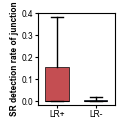

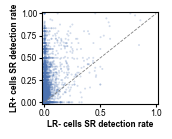

  [verify] LR+ 0.104204 | LR- 0.013314 | ratio 7.827x


In [8]:
# Per-cell inputs, tried in order of how well they match the rest of the notebook:
#   1. VALDIR                -- whatever carrier scope sections 1-4 are using
#   2. validation_option1/   -- option-1 targets, novel-only carriers (job 38641485, 48 samples)
# Step 2 matters because VALDIR moves to the carrier-unfiltered directory as soon as that run
# exists, and validate_percell_all.py has not been re-run under that scope -- without this rung
# the section would skip straight past perfectly good option-1 per-cell results to the FL>=5
# ones. Whichever rung is used is announced, and anything below the first is flagged as not
# comparable with sections 1-4.
#
# The notebook dedup convention does not apply here: the per-cell unit is intrinsically
# (isoform, junction), because LR+ cells are defined as cells expressing that isoform.
# Only option-1 scopes remain.
_PC_CHAIN = [(VALDIR, "matches sections 1-4"),
             (VALDIR_NOV, "option-1 targets, NIC/NNC carriers only")]
PERCELL_DIR, PERCELL_NOTE, pc_files = None, None, []
for _d, _note in _PC_CHAIN:
    _f = sorted(glob.glob(f"{_d}/T*_percell_junction_validation.csv"))
    if _f:
        PERCELL_DIR, PERCELL_NOTE, pc_files = _d, _note, _f
        break

if not pc_files:
    print("No per-cell results anywhere - run sr_junction_validation/run_percell_option1.sbatch.")
else:
    print(f"Per-cell samples: {len(pc_files)} from {PERCELL_DIR}\n  ({PERCELL_NOTE})")
    if PERCELL_DIR != VALDIR:
        print(f"  !! this is NOT the target set sections 1-4 are using ({VALDIR}).")
        print(f"     Read section 5 as a separate analysis; its numbers are not directly")
        print(f"     comparable with sections 1-4 or 6. To align it, re-run")
        print(f"     validate_percell_all.py against the same targets.\n")
    pcs = []
    for fp in pc_files:
        t = re.match(r".*/(T\d+)_percell", fp).group(1)
        d = pd.read_csv(fp, usecols=["isoform", "n_lr_plus", "sr_rate_plus", "sr_rate_minus"])
        d["tissue"] = t
        pcs.append(d)
    pc = pd.concat(pcs, ignore_index=True)
    del pcs
    q = pc[pc["n_lr_plus"] >= 5].dropna(subset=["sr_rate_minus"]).copy()
    print(f"junctions with >=5 LR+ cells and LR- cells: {len(q):,} across {q['tissue'].nunique()} sample(s)")
    print(f"  mean SR-detection rate  LR+: {q['sr_rate_plus'].mean():.3f} | LR-: {q['sr_rate_minus'].mean():.3f}")
    print(f"  LR+ > LR- in {(q['sr_rate_plus'] > q['sr_rate_minus']).mean():.1%} of junctions")
    from scipy.stats import wilcoxon
    try:
        _, pval = wilcoxon(q["sr_rate_plus"], q["sr_rate_minus"]); print(f"  paired Wilcoxon p = {pval:.2e}")
    except Exception as e:
        pval = np.nan; print("  wilcoxon:", e)

    # (a) paired box
    fig, ax1 = plt.subplots(figsize=(1.0, 1.2))
    bp = ax1.boxplot([q["sr_rate_plus"], q["sr_rate_minus"]], widths=0.6, showfliers=False,
                     patch_artist=True, medianprops=dict(color="black", lw=0.8))
    for patch, col in zip(bp["boxes"], ["#c44e52", "#4c72b0"]):
        patch.set_facecolor(col); patch.set_edgecolor("black"); patch.set_linewidth(0.5)
    ax1.set_xticks([1, 2]); ax1.set_xticklabels(["LR+", "LR-"])
    ax1.set_ylabel("SR detection rate of junction")
    # ax1.set_title(f"per-cell SR detection\n(Wilcoxon p={pval:.1e})", pad=PANEL_TITLE_PAD)
    plt.savefig(figpath("03_06b_percell_LRpos_vs_LRneg_box.pdf"),  dpi=300)
    plt.show()

    # (b) scatter LR+ vs LR- (subsample for legibility)
    fig, ax2 = plt.subplots(figsize=(1.5, 1.2))
    s = q.sample(min(len(q), 8000), random_state=0)
    ax2.scatter(s["sr_rate_minus"], s["sr_rate_plus"], s=2, alpha=0.25, edgecolors="none", color="#4c72b0")
    ax2.plot([0, 1], [0, 1], "--", color="grey", lw=0.6)
    ax2.set_xlabel("LR- cells SR detection rate"); ax2.set_ylabel("LR+ cells SR detection rate")
    # ax2.set_title("above y=x -> validated in LR+ cells", pad=PANEL_TITLE_PAD)
    ax2.set_xlim(-0.02, 1.02); ax2.set_ylim(-0.02, 1.02)
    plt.savefig(figpath("03_06b_percell_LRpos_vs_LRneg_scatter.pdf"), dpi=300)
    plt.show()

    # [verify] the draft's "~7.8-fold enrichment". The 3-dp rates printed above give
    # 0.104 / 0.013 = 8.0, which cannot settle it; print the unrounded ratio.
    _rp = float(q["sr_rate_plus"].mean()); _rm = float(q["sr_rate_minus"].mean())
    print(f"  [verify] LR+ {_rp:.6f} | LR- {_rm:.6f} | ratio {_rp / _rm:.3f}x")


## 6. Does validation depend on where the junction sits along the transcript?

Same analysis as the position section of the FL-based notebook, on the option-1 isoform set.
Reads `sr_junction_validation/validation_positions_option1_allknown_robust_all/`, built by
`validate_positions_option1_allknown.py` with SCOPE=`robust_all`.

Tests whether the SR validation rate of a novel junction depends on its **relative position
between the 5' and 3' end**, measured as `rel_iso`, the junction midpoint within the isoform's
genomic span, where 0 is the transcript 5' end and 1 the 3' end.

`rel_iso` is strand-oriented explicitly. SQANTI numbers junctions and reports coordinates in
**genomic** order regardless of strand, so the fraction is flipped for `-` strand isoforms.

Being a genomic measure, `rel_iso` is not transcript position. The denominator
`iso_end - iso_start` is dominated by intron length, so a junction flanking a long intron sits at
a genomic position that does not correspond to where it falls in the mature mRNA. Read it as
position within the isoform's genomic footprint.

**The known-junction control is the whole point, not a nicety.** The short-read libraries are
10x 3'-biased, so STARsolo's power to see *any* junction falls off with distance from the 3' end.
A novel-only curve therefore measures SR coverage rather than long-read reliability. The known
curve estimates SR detection power, and the **novel-vs-known gap at matched position** is the
long-read-specific effect.

Two sets are plotted.

| set | definition | role |
|---|---|---|
| `novel` | every novel canonical junction, any carrier isoform | the target set |
| `known_all` | known canonical junctions of every pbids-object isoform | the control |

`known_all` is named that rather than plain `known` to stay distinct from section 2's `LR_known`,
which is every known canonical junction in the tissue with no isoform quality floor.

`known_all` trades isoform-level matching for a control clear of the detection ceiling, so part
of its lower absolute rate is expression rather than position — **read its shape, not its level**.
The interpretable quantity is the novel-vs-known **gap**, compared on the **odds scale, not in
percentage points**. Dedup is within tissue, not atlas-wide, so a junction present in many
samples contributes once per sample and the pooled bins are not independent observations.

Prerequisite: `sbatch sr_junction_validation/run_validate_positions_option1_allknown.sbatch`.
SCOPE=`all` would additionally drop the quality floor and write to `..._allknown_all/`. The cells
below no-op with a message until the outputs exist.

In [9]:
# Accumulate BINNED counts per tissue rather than concatenating all 48 files. The broadened
# known set is ~7x the old target-isoform one (55.9M rows over 48 samples, 3.3 GB of CSV, up
# to 225 MB in a single tissue), so pooling raw rows would blow up memory and let the deepest
# sample dominate. One tissue is in memory at a time; per-tissue rates are also kept, for the
# spread across samples. Still a heavy read -- run on a compute node.
SCOPE = "robust_all"     # "all" would need run_validate_positions_option1_allknown.sbatch with SCOPE=all
POSDIR = f"./../sr_junction_validation/validation_positions_option1_allknown_{SCOPE}"
NBINS = 20
edges = np.linspace(0, 1, NBINS + 1)
centers = (edges[:-1] + edges[1:]) / 2
CATS = ["novel", "known_all"]
METRIC_LABEL = "Position within isoform\n(0 = 5' end, 1 = 3' end)"
# Named known_all, not plain "known", to stay distinct from section 1's LR_known: that one is
# every known canonical junction in the tissue with no isoform filter at all, this one is every
# known canonical junction of an isoform passing the pbids-object quality floor.
SET_LABEL_POS = {"novel": "novel", "known_all": "known (all isoforms)"}

# NO carrier-isoform filter on the novel arm: every novel canonical junction counts, whatever
# structural category its isoform has. This is a junction-level question ("do novel junctions
# validate?"), so the carrier's category is not part of the definition.
#
# CONSEQUENCE: this arm is NOT the same population as sections 1-4, whose target set is
# NIC/NNC isoforms only. The extra ~3.7% ride on genic/fusion/antisense isoforms and validate
# at a similar rate, so the curves barely move -- but the TOTALS are not comparable across
# sections. The composition is printed below.

# Dedup follows the notebook-wide convention DECLARED IN THE SETUP CELL (DEDUP_NOVEL /
# DEDUP_KNOWN); it is not redefined here. Both arms deduplicate to distinct (chrom, start,
# end) within each tissue, so the novel-minus-known gap subtracts two rates over the same
# unit of analysis.
DEDUP_BY_SET = {"novel": DEDUP_NOVEL, "known_all": DEDUP_KNOWN}
DEDUP_KEYS = ["chrom", "junc_start", "junc_end"]   # the positioned files' column names for
                                                   # (chrom, start, end)
if (DEDUP_NOVEL, DEDUP_KNOWN) != UPSTREAM_DEDUP:
    print(f"note: this section counts novel={DEDUP_LABEL[DEDUP_NOVEL]}, "
          f"known={DEDUP_LABEL[DEDUP_KNOWN]}, which differs from the summary CSV behind "
          f"section 2 -- the two sets of totals are not comparable.\n")
# Caveat: deduplicating keeps an arbitrary carrier isoform, so a junction's rel_iso comes
# from whichever isoform happened to be first in the file. Now applies to BOTH arms.

pos_files = sorted(glob.glob(f"{POSDIR}/T*_positioned_junction_SR_support.csv"))
if not pos_files:
    print(f"No positioned outputs in {POSDIR} - run: "
          f"sbatch sr_junction_validation/run_validate_positions_option1_allknown.sbatch")
    posagg = per_tissue_pos = None
else:
    n_tot = {c: np.zeros(NBINS, dtype=np.int64) for c in CATS}
    n_hit = {c: np.zeros(NBINS, dtype=np.int64) for c in CATS}
    per_tissue_rows, n_rows, n_dropped = [], 0, 0
    n_novel_nic_nnc = 0        # descriptive only -- no longer a filter

    for fp in pos_files:
        t = re.match(r".*/(T\d+)_positioned", fp).group(1)
        d = pd.read_csv(fp, usecols=["chrom", "strand", "junc_start", "junc_end",
                                     "junction_category", "iso_start", "iso_end",
                                     "is_novel_isoform", "sr_matched"],
                        dtype={"chrom": "category", "strand": "category",
                               "junction_category": "category"})

        is_nov_cat = d["junction_category"] == "novel"
        nov = d[is_nov_cat]
        n_novel_nic_nnc += int((is_nov_cat & d["is_novel_isoform"].astype(bool)).sum())
        kn = d[d["junction_category"] == "known"]
        del d

        _parts = []
        for _c, _s in [("novel", nov), ("known_all", kn)]:
            _s = _s.copy()
            if DEDUP_BY_SET[_c]:
                _n0 = len(_s)
                _s = _s.drop_duplicates(DEDUP_KEYS)
                n_dropped += _n0 - len(_s)
            _s["set"] = _c
            _parts.append(_s)
        d = pd.concat(_parts, ignore_index=True)
        del _parts, nov, kn
        if not len(d):
            continue
        n_rows += len(d)

        # --- isoform-relative position (genomic span of the isoform), oriented 5' -> 3' ---
        jmid = (d["junc_start"].to_numpy(float) + d["junc_end"].to_numpy(float)) / 2.0
        minus = (d["strand"].astype(str).to_numpy() == "-")
        span = d["iso_end"].to_numpy(float) - d["iso_start"].to_numpy(float)
        with np.errstate(invalid="ignore", divide="ignore"):
            rel = (jmid - d["iso_start"].to_numpy(float)) / np.where(span > 0, span, np.nan)
        d["rel_iso"] = np.where(minus, 1.0 - rel, rel)

        cat = d["set"].to_numpy()
        hit = d["sr_matched"].to_numpy().astype(bool)
        v = d["rel_iso"].to_numpy(float)
        # tolerate float slop at the ends, drop anything genuinely outside the span
        ok = np.isfinite(v) & (v >= -1e-3) & (v <= 1 + 1e-3)
        idx = np.minimum((np.clip(v[ok], 0, 1) * NBINS).astype(int), NBINS - 1)
        trow = {"tissue": t}
        for c in CATS:
            sel = cat[ok] == c
            n_tot[c] += np.bincount(idx[sel], minlength=NBINS)
            n_hit[c] += np.bincount(idx[sel][hit[ok][sel]], minlength=NBINS)
            # per-tissue 5'-most vs 3'-most quintile, for the across-sample spread
            q = idx[sel]; h = hit[ok][sel]
            lo, hi = q < NBINS // 5, q >= NBINS - NBINS // 5
            trow[f"{c}_5p"] = h[lo].mean() if lo.sum() else np.nan
            trow[f"{c}_3p"] = h[hi].mean() if hi.sum() else np.nan
        per_tissue_rows.append(trow)
        del d

    per_tissue_pos = pd.DataFrame(per_tissue_rows)
    posagg = pd.DataFrame([{"set": c, "bin": i, "center": centers[i],
                            "n": int(n_tot[c][i]), "matched": int(n_hit[c][i])}
                           for c in CATS for i in range(NBINS)])
    posagg["match_frac"] = posagg["matched"] / posagg["n"].replace(0, np.nan)
    posagg.to_csv("./../csvs/sr_junction_validation_by_position_option1_allknown.csv", index=False)

    print(f"source: {POSDIR}")
    print("junction counting (setup-cell convention): "
          + ", ".join(f"{c}={DEDUP_LABEL[DEDUP_BY_SET[c]]}" for c in CATS)
          + f" -- dropped {n_dropped:,} duplicate copies")
    _nov_tot = int(posagg[posagg["set"] == "novel"]["n"].sum())
    print(f"novel arm: every novel canonical junction, no carrier-isoform filter "
          f"({n_novel_nic_nnc:,} of the pre-dedup occurrences were carried by NIC/NNC isoforms, "
          f"the rest by genic/fusion/antisense carriers)")
    print(f"positioned junctions pooled over {len(pos_files)} samples: {n_rows:,} rows")
    for c in CATS:
        s = posagg[posagg["set"] == c]
        n, hi = int(s["n"].sum()), int(s["matched"].sum())
        print(f"  rel_iso {c:10s}: n={n:>12,} | overall match {hi/max(n,1):.1%}")
    # The summary deduplicates its novel arm too, so this total and section 2's
    # LR_novel__canonical should be IDENTICAL. Check it rather than assert a
    # relationship in prose -- if they diverge, one of the two builds is stale.
    print(f"  novel n={_nov_tot:,} distinct (tissue, coordinate) pairs; section 2's "
          f"LR_novel__canonical should match exactly (both deduplicated, both canonical).")
    # Sanity check on the control: it has to MOVE with position to be worth subtracting.
    _ka = posagg[posagg["set"] == "known_all"]
    print(f"  known_all dynamic range (max-min bin): "
          f"{(_ka['match_frac'].max() - _ka['match_frac'].min()) * 100:.1f}pp "
          f"-- the control has to MOVE with position to be worth subtracting")

source: ./../sr_junction_validation/validation_positions_option1_allknown_robust_all
junction counting (setup-cell convention): novel=distinct coords, known_all=distinct coords -- dropped 49,391,447 duplicate copies
novel arm: every novel canonical junction, no carrier-isoform filter (3,167,801 of the pre-dedup occurrences were carried by NIC/NNC isoforms, the rest by genic/fusion/antisense carriers)
positioned junctions pooled over 48 samples: 9,829,965 rows
  rel_iso novel     : n=   2,374,498 | overall match 39.6%
  rel_iso known_all : n=   7,455,467 | overall match 84.9%
  novel n=2,374,498 distinct (tissue, coordinate) pairs; section 2's LR_novel__canonical should match exactly (both deduplicated, both canonical).
  known_all dynamic range (max-min bin): 12.9pp -- the control has to MOVE with position to be worth subtracting


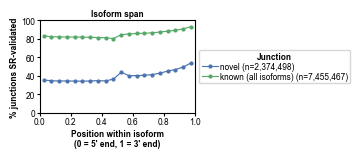

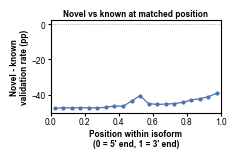

set          5-prime bin  3-prime bin   3p - 5p     per-sample 3p-5p (mean +/- SD)
novel             35.3%        53.8%     18.5pp              16.9pp +/- 5.8
known_all         83.3%        93.1%      9.8pp               8.6pp +/- 3.2

GAP novel - known_all: -48.0pp at 5' -> -39.3pp at 3' | range -48.0 to -39.3pp


In [10]:
if posagg is None:
    print("Run the previous cell's prerequisite first.")
else:
    MIN_N = 200                      # don't plot a bin backed by too few junctions
    COL = {"novel": "#4c72b0", "known_all": "#55a868"}
    CONTROL = "known_all"

    # ---- Figure 1: validation rate vs rel_iso, novel vs the known control ----
    fig, ax = plt.subplots(figsize=(2.0, 1.2))
    for c in CATS:
        s = posagg[posagg["set"] == c].sort_values("center")
        s = s[s["n"] >= MIN_N]
        se = np.sqrt(s["match_frac"] * (1 - s["match_frac"]) / s["n"])   # binomial SE
        ax.plot(s["center"], s["match_frac"] * 100, "-", marker="o", ms=2.0, lw=0.8,
                color=COL[c], label=f"{SET_LABEL_POS[c]} (n={s['n'].sum():,})")
        ax.fill_between(s["center"], (s["match_frac"] - 1.96 * se) * 100,
                        (s["match_frac"] + 1.96 * se) * 100, color=COL[c], alpha=0.25, lw=0)
    ax.set_xlabel(METRIC_LABEL)
    ax.set_ylabel("% junctions SR-validated")
    ax.set_xlim(0, 1); ax.set_ylim(0, 100)
    ax.set_title("Isoform span", pad=PANEL_TITLE_PAD)
    leg = ax.legend(loc=6, bbox_to_anchor=(1.0, 0.5), title="Junction")
    leg.get_title().set_fontweight("bold")
    plt.savefig(figpath("03_06b_validation_vs_relative_position_allknown.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()

    # ---- Figure 2: the interpretable quantity -- novel MINUS known at matched position ----
    # Known junctions absorb the 10x 3' coverage gradient, so a flat gap means novel junctions
    # are no less reliable at the 5' end; a gap that widens toward 0 would mean a genuine
    # long-read-specific 5' problem.
    nv = posagg[posagg["set"] == "novel"].set_index("bin")
    kn = posagg[posagg["set"] == CONTROL].set_index("bin")
    ok = (nv["n"] >= MIN_N) & (kn["n"] >= MIN_N)
    gap = (nv.loc[ok, "match_frac"] - kn.loc[ok, "match_frac"]) * 100

    fig, ax = plt.subplots(figsize=(2.2, 1.2))
    ax.plot(nv.loc[ok, "center"], gap, "-", marker="o", ms=2.0, lw=0.9, color="#4c72b0")
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.set_xlabel(METRIC_LABEL)
    ax.set_ylabel("Novel - known\nvalidation rate (pp)")
    ax.set_xlim(0, 1)
    ax.set_title("Novel vs known at matched position", pad=PANEL_TITLE_PAD)
    plt.savefig(figpath("03_06b_validation_position_novel_minus_known_allknown.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()

    # ---- printed summary: 5'-most vs 3'-most bin, pooled and across samples ----
    print(f"{'set':11s} {'5-prime bin':>12s} {'3-prime bin':>12s} {'3p - 5p':>9s}"
          f"   {'per-sample 3p-5p (mean +/- SD)':>32s}")
    for c in CATS:
        s = posagg[posagg["set"] == c].sort_values("center")
        s = s[s["n"] >= MIN_N]
        if not len(s):
            continue
        lo, hi = s["match_frac"].iloc[0], s["match_frac"].iloc[-1]
        dt = per_tissue_pos[f"{c}_3p"] - per_tissue_pos[f"{c}_5p"]
        print(f"{c:11s} {lo:11.1%} {hi:12.1%} {(hi-lo)*100:8.1f}pp"
              f"   {dt.mean()*100:>15.1f}pp +/- {dt.std()*100:.1f}")
    print(f"\nGAP novel - {CONTROL}: {gap.iloc[0]:.1f}pp at 5' -> {gap.iloc[-1]:.1f}pp at 3'"
          f" | range {gap.min():.1f} to {gap.max():.1f}pp")